In [4]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.stats import pearsonr, t

def pythagorean_win_pct(runs_scored, runs_allowed, exponent):
    """Calculate Pythagorean win expectation"""
    return runs_scored**exponent / (runs_scored**exponent + runs_allowed**exponent)

def sum_squared_error(exponent, actual_win_pct, runs_scored, runs_allowed):
    """Calculate sum of squared errors between actual and predicted win percentages"""
    predicted = pythagorean_win_pct(runs_scored, runs_allowed, exponent)
    return np.sum((actual_win_pct - predicted)**2)

def find_optimal_exponent(actual_win_pct, runs_scored, runs_allowed):
    """Find optimal Pythagorean exponent by minimizing SSE"""
    result = minimize_scalar(
        sum_squared_error,
        bounds=(1.0, 3.0),
        method='bounded',
        args=(actual_win_pct, runs_scored, runs_allowed)
    )
    return result.x

def calculate_metrics(actual_win_pct, runs_scored, runs_allowed, exponent):
    """Calculate fit metrics for a given exponent"""
    predicted = pythagorean_win_pct(runs_scored, runs_allowed, exponent)
    
    # Sum of Squared Errors
    sse = np.sum((actual_win_pct - predicted)**2)
    
    # Root Mean Squared Error
    rmse = np.sqrt(np.mean((actual_win_pct - predicted)**2))
    
    # Mean Absolute Error
    mae = np.mean(np.abs(actual_win_pct - predicted))
    
    # R-squared
    r_squared = 1 - (sse / np.sum((actual_win_pct - np.mean(actual_win_pct))**2))
    
    # Correlation
    correlation, _ = pearsonr(actual_win_pct, predicted)
    
    return {
        'SSE': sse,
        'RMSE': rmse,
        'MAE': mae,
        'R_squared': r_squared,
        'Correlation': correlation,
        'Predicted': predicted
    }

def compare_exponents(actual_win_pct, runs_scored, runs_allowed, exp1, exp2, label1="Optimal", label2="1.83"):
    """Compare two exponents and test for statistical significance"""
    metrics1 = calculate_metrics(actual_win_pct, runs_scored, runs_allowed, exp1)
    metrics2 = calculate_metrics(actual_win_pct, runs_scored, runs_allowed, exp2)
    
    # Calculate residuals
    residuals1 = actual_win_pct - metrics1['Predicted']
    residuals2 = actual_win_pct - metrics2['Predicted']
    
    # Paired t-test on squared errors
    squared_errors1 = residuals1**2
    squared_errors2 = residuals2**2
    
    # Calculate difference in squared errors
    diff = squared_errors1 - squared_errors2
    n = len(diff)
    
    # T-statistic
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    t_stat = mean_diff / (std_diff / np.sqrt(n))
    
    # P-value (two-tailed)
    p_value = 2 * (1 - t.cdf(abs(t_stat), n - 1))
    
    return {
        'exp1': exp1,
        'exp2': exp2,
        'label1': label1,
        'label2': label2,
        'metrics1': metrics1,
        'metrics2': metrics2,
        't_statistic': t_stat,
        'p_value': p_value,
        'n': n
    }

# Load your actual data
# Replace 'your_file.csv' with your actual file path
df = pd.read_csv('ncaabb_teamStats.csv')

# Map column names to what the script expects
# Your CSV has:
# - 'team' -> Team name
# - 'league' -> Conference
# - 'year' -> Year
# - 'W' -> Wins
# - 'L' -> Losses  
# - 'WPCT' -> Win percentage (already calculated)
# - 'R (Batting)' -> Runs scored
# - 'R (Pitching)' -> Runs allowed

df = df.rename(columns={
    'team': 'Team',
    'league': 'Conference',
    'year': 'Year',
    'W': 'Wins',
    'L': 'Losses',
    'WPCT': 'Win_Pct',
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

# Filter for years 2021-2025
df = df[df['Year'].between(2021, 2025)]

# Remove any rows with missing data
df = df.dropna(subset=['Win_Pct', 'R', 'RA'])

# Remove ties from games count if needed for recalculating win pct
# (WPCT in your data should already be correct)

print("=" * 80)
print("PYTHAGOREAN EXPECTATION OPTIMIZATION FOR COLLEGE BASEBALL")
print("=" * 80)
print()

# Overall optimization (all teams, all years)
print("OVERALL ANALYSIS (All Teams, 2021-2025)")
print("-" * 80)

optimal_exp = find_optimal_exponent(
    df['Win_Pct'].values,
    df['R'].values,
    df['RA'].values
)

# Compare optimal vs 1.83
comparison = compare_exponents(
    df['Win_Pct'].values,
    df['R'].values,
    df['RA'].values,
    optimal_exp,
    1.83,
    f"Optimal ({optimal_exp:.4f})",
    "Standard (1.83)"
)

print(f"Optimal Exponent: {optimal_exp:.4f}")
print(f"Sample Size: {len(df)} team-seasons")
print()

print("COMPARISON: Optimal vs Standard (1.83) Exponent")
print("-" * 80)
print(f"{'Metric':<20} {'Optimal (' + f'{optimal_exp:.4f})':>15} {'Standard (1.83)':>15} {'Difference':>12}")
print("-" * 80)
print(f"{'R-squared':<20} {comparison['metrics1']['R_squared']:>15.4f} {comparison['metrics2']['R_squared']:>15.4f} {comparison['metrics1']['R_squared'] - comparison['metrics2']['R_squared']:>12.4f}")
print(f"{'Correlation':<20} {comparison['metrics1']['Correlation']:>15.4f} {comparison['metrics2']['Correlation']:>15.4f} {comparison['metrics1']['Correlation'] - comparison['metrics2']['Correlation']:>12.4f}")
print(f"{'RMSE':<20} {comparison['metrics1']['RMSE']:>15.4f} {comparison['metrics2']['RMSE']:>15.4f} {comparison['metrics1']['RMSE'] - comparison['metrics2']['RMSE']:>12.4f}")
print(f"{'MAE':<20} {comparison['metrics1']['MAE']:>15.4f} {comparison['metrics2']['MAE']:>15.4f} {comparison['metrics1']['MAE'] - comparison['metrics2']['MAE']:>12.4f}")
print(f"{'SSE':<20} {comparison['metrics1']['SSE']:>15.4f} {comparison['metrics2']['SSE']:>15.4f} {comparison['metrics1']['SSE'] - comparison['metrics2']['SSE']:>12.4f}")
print()

print("STATISTICAL SIGNIFICANCE TEST")
print("-" * 80)
print(f"Paired t-test on squared prediction errors:")
print(f"  t-statistic: {comparison['t_statistic']:>8.4f}")
print(f"  p-value:     {comparison['p_value']:>8.6f}")
print(f"  Sample size: {comparison['n']:>8d}")
print()

if comparison['p_value'] < 0.001:
    sig_level = "p < 0.001 (***)"
    interpretation = "HIGHLY SIGNIFICANT"
elif comparison['p_value'] < 0.01:
    sig_level = "p < 0.01 (**)"
    interpretation = "VERY SIGNIFICANT"
elif comparison['p_value'] < 0.05:
    sig_level = "p < 0.05 (*)"
    interpretation = "SIGNIFICANT"
else:
    sig_level = f"p = {comparison['p_value']:.4f} (ns)"
    interpretation = "NOT SIGNIFICANT"

print(f"  Significance: {sig_level}")
print(f"  Interpretation: {interpretation}")
print()

if comparison['p_value'] < 0.05:
    if optimal_exp > 1.83:
        print(f"  → The optimal exponent ({optimal_exp:.4f}) is significantly HIGHER than 1.83")
        print(f"  → This suggests blowouts are MORE predictive in college baseball")
    else:
        print(f"  → The optimal exponent ({optimal_exp:.4f}) is significantly LOWER than 1.83")
        print(f"  → This suggests blowouts are LESS predictive in college baseball")
else:
    print(f"  → No significant difference between {optimal_exp:.4f} and 1.83")
    print(f"  → Using 1.83 (the common baseball standard) is reasonable")
print()

# Conference-specific optimization
print("\nCONFERENCE-SPECIFIC ANALYSIS")
print("-" * 80)

conference_results = []

for conference in sorted(df['Conference'].unique()):
    conf_data = df[df['Conference'] == conference]
    
    if len(conf_data) < 10:  # Skip conferences with too few observations
        continue
    
    conf_optimal = find_optimal_exponent(
        conf_data['Win_Pct'].values,
        conf_data['R'].values,
        conf_data['RA'].values
    )
    
    conf_metrics_opt = calculate_metrics(
        conf_data['Win_Pct'].values,
        conf_data['R'].values,
        conf_data['RA'].values,
        conf_optimal
    )
    
    conf_metrics_183 = calculate_metrics(
        conf_data['Win_Pct'].values,
        conf_data['R'].values,
        conf_data['RA'].values,
        1.83
    )
    
    # Test significance for this conference
    conf_comparison = compare_exponents(
        conf_data['Win_Pct'].values,
        conf_data['R'].values,
        conf_data['RA'].values,
        conf_optimal,
        1.83
    )
    
    conference_results.append({
        'Conference': conference,
        'Exponent': conf_optimal,
        'N': len(conf_data),
        'R²_Optimal': conf_metrics_opt['R_squared'],
        'R²_1.83': conf_metrics_183['R_squared'],
        'RMSE_Optimal': conf_metrics_opt['RMSE'],
        'RMSE_1.83': conf_metrics_183['RMSE'],
        'p_value': conf_comparison['p_value']
    })

conf_results_df = pd.DataFrame(conference_results)
conf_results_df = conf_results_df.sort_values('Exponent', ascending=False)

# Add significance markers
conf_results_df['Sig'] = conf_results_df['p_value'].apply(
    lambda p: '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else ''
)

print(conf_results_df.to_string(index=False))
print()
print("Significance: *** p<0.001, ** p<0.01, * p<0.05")
print()

# Summary statistics
print("\nSUMMARY STATISTICS")
print("-" * 80)
print(f"Overall Optimal Exponent: {optimal_exp:.4f}")
print(f"Conference Exponents - Mean: {conf_results_df['Exponent'].mean():.4f}")
print(f"Conference Exponents - Std Dev: {conf_results_df['Exponent'].std():.4f}")
print(f"Conference Exponents - Range: [{conf_results_df['Exponent'].min():.4f}, {conf_results_df['Exponent'].max():.4f}]")
print()
print(f"Conferences with significant difference from 1.83 (p<0.05): {(conf_results_df['p_value'] < 0.05).sum()} of {len(conf_results_df)}")
print()

# Save results for visualization
results_for_viz = {
    'df': df,
    'optimal_exp': optimal_exp,
    'conf_results_df': conf_results_df,
    'comparison': comparison
}

# Export results to CSV
conf_results_df.to_csv('conference_exponents.csv', index=False)
print("Conference results saved to 'conference_exponents.csv'")
print()

PYTHAGOREAN EXPECTATION OPTIMIZATION FOR COLLEGE BASEBALL

OVERALL ANALYSIS (All Teams, 2021-2025)
--------------------------------------------------------------------------------
Optimal Exponent: 1.7891
Sample Size: 1468 team-seasons

COMPARISON: Optimal vs Standard (1.83) Exponent
--------------------------------------------------------------------------------
Metric               Optimal (1.7891) Standard (1.83)   Difference
--------------------------------------------------------------------------------
R-squared                     0.8932          0.8929       0.0004
Correlation                   0.9458          0.9458       0.0000
RMSE                          0.0459          0.0459      -0.0001
MAE                           0.0364          0.0363       0.0000
SSE                           3.0875          3.0977      -0.0102

STATISTICAL SIGNIFICANCE TEST
--------------------------------------------------------------------------------
Paired t-test on squared prediction errors:


Visualization saved as 'pythagorean_exponent_analysis.png'


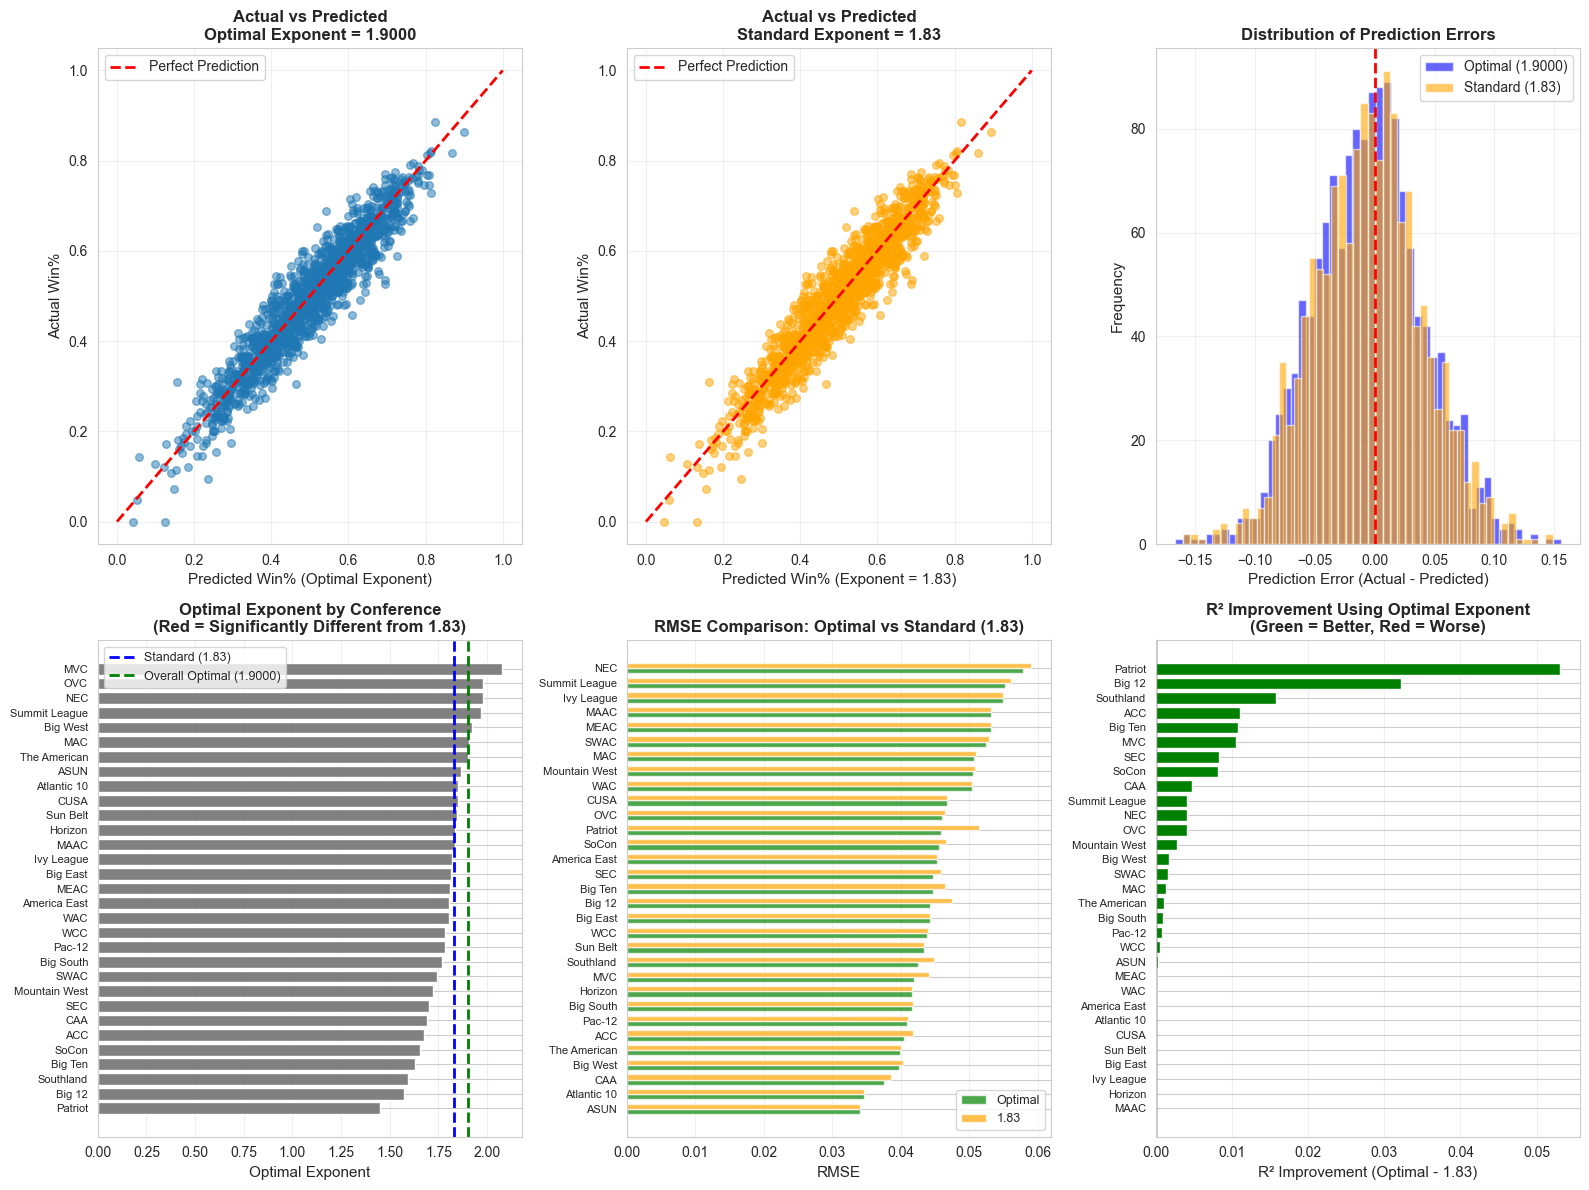

Yearly trends saved as 'pythagorean_yearly_trends.png'


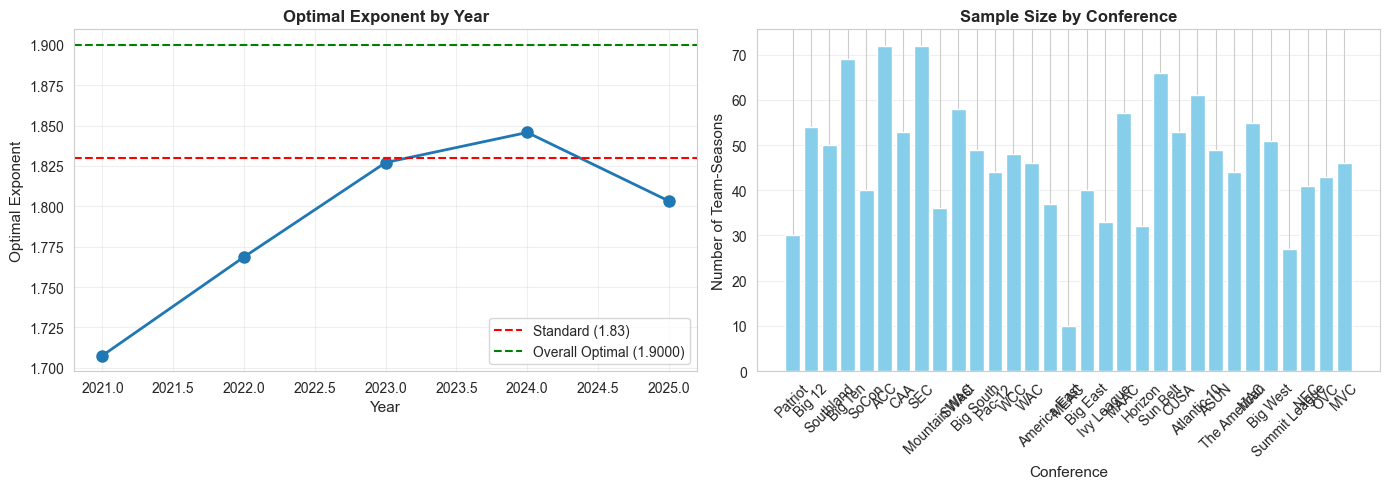


VISUALIZATION COMPLETE

Generated plots:
1. Actual vs Predicted (Optimal exponent)
2. Actual vs Predicted (1.83 exponent)
3. Distribution of prediction errors
4. Optimal exponent by conference (with significance)
5. RMSE comparison by conference
6. R² improvement by conference
7. Optimal exponent trends by year
8. Sample size by conference


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

# Load the data (assumes you've run the optimization script first)
# Replace with your actual file path
df = pd.read_csv('ncaabb_teamStats.csv')

df = df.rename(columns={
    'team': 'Team',
    'league': 'Conference',
    'year': 'Year',
    'W': 'Wins',
    'L': 'Losses',
    'WPCT': 'Win_Pct',
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[df['Year'].between(2021, 2025)]
df = df.dropna(subset=['Win_Pct', 'R', 'RA'])

# Load conference results
conf_results_df = pd.read_csv('conference_exponents.csv')

# Calculate optimal exponent (simplified for visualization)
def pythagorean_win_pct(runs_scored, runs_allowed, exponent):
    return runs_scored**exponent / (runs_scored**exponent + runs_allowed**exponent)

# You'll need to set this to your calculated optimal exponent
# This is just a placeholder - replace with actual value from optimization
optimal_exp = 1.90  # REPLACE THIS with your actual optimal exponent

# Calculate predictions
df['Pyth_Optimal'] = pythagorean_win_pct(df['R'], df['RA'], optimal_exp)
df['Pyth_183'] = pythagorean_win_pct(df['R'], df['RA'], 1.83)
df['Error_Optimal'] = df['Win_Pct'] - df['Pyth_Optimal']
df['Error_183'] = df['Win_Pct'] - df['Pyth_183']

# Create figure with subplots
fig = plt.figure(figsize=(16, 12))

# 1. Actual vs Predicted (Optimal)
ax1 = plt.subplot(2, 3, 1)
ax1.scatter(df['Pyth_Optimal'], df['Win_Pct'], alpha=0.5, s=30)
ax1.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
ax1.set_xlabel('Predicted Win% (Optimal Exponent)', fontsize=11)
ax1.set_ylabel('Actual Win%', fontsize=11)
ax1.set_title(f'Actual vs Predicted\nOptimal Exponent = {optimal_exp:.4f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Actual vs Predicted (1.83)
ax2 = plt.subplot(2, 3, 2)
ax2.scatter(df['Pyth_183'], df['Win_Pct'], alpha=0.5, s=30, color='orange')
ax2.plot([0, 1], [0, 1], 'r--', lw=2, label='Perfect Prediction')
ax2.set_xlabel('Predicted Win% (Exponent = 1.83)', fontsize=11)
ax2.set_ylabel('Actual Win%', fontsize=11)
ax2.set_title('Actual vs Predicted\nStandard Exponent = 1.83', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. Residual comparison
ax3 = plt.subplot(2, 3, 3)
ax3.hist(df['Error_Optimal'], bins=50, alpha=0.6, label=f'Optimal ({optimal_exp:.4f})', color='blue')
ax3.hist(df['Error_183'], bins=50, alpha=0.6, label='Standard (1.83)', color='orange')
ax3.axvline(0, color='red', linestyle='--', lw=2)
ax3.set_xlabel('Prediction Error (Actual - Predicted)', fontsize=11)
ax3.set_ylabel('Frequency', fontsize=11)
ax3.set_title('Distribution of Prediction Errors', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. Conference exponents
ax4 = plt.subplot(2, 3, 4)
conf_sorted = conf_results_df.sort_values('Exponent')
colors = ['red' if p < 0.05 else 'gray' for p in conf_sorted['p_value']]
bars = ax4.barh(range(len(conf_sorted)), conf_sorted['Exponent'], color=colors)
ax4.axvline(1.83, color='blue', linestyle='--', lw=2, label='Standard (1.83)')
ax4.axvline(optimal_exp, color='green', linestyle='--', lw=2, label=f'Overall Optimal ({optimal_exp:.4f})')
ax4.set_yticks(range(len(conf_sorted)))
ax4.set_yticklabels(conf_sorted['Conference'], fontsize=8)
ax4.set_xlabel('Optimal Exponent', fontsize=11)
ax4.set_title('Optimal Exponent by Conference\n(Red = Significantly Different from 1.83)', fontsize=12, fontweight='bold')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='x')

# 5. RMSE Comparison by Conference
ax5 = plt.subplot(2, 3, 5)
conf_sorted2 = conf_results_df.sort_values('RMSE_Optimal')
x = np.arange(len(conf_sorted2))
width = 0.35
ax5.barh(x - width/2, conf_sorted2['RMSE_Optimal'], width, label='Optimal', color='green', alpha=0.7)
ax5.barh(x + width/2, conf_sorted2['RMSE_1.83'], width, label='1.83', color='orange', alpha=0.7)
ax5.set_yticks(x)
ax5.set_yticklabels(conf_sorted2['Conference'], fontsize=8)
ax5.set_xlabel('RMSE', fontsize=11)
ax5.set_title('RMSE Comparison: Optimal vs Standard (1.83)', fontsize=12, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3, axis='x')

# 6. R² Improvement
ax6 = plt.subplot(2, 3, 6)
conf_results_df['R2_Improvement'] = conf_results_df['R²_Optimal'] - conf_results_df['R²_1.83']
conf_sorted3 = conf_results_df.sort_values('R2_Improvement')
colors2 = ['green' if x > 0 else 'red' for x in conf_sorted3['R2_Improvement']]
ax6.barh(range(len(conf_sorted3)), conf_sorted3['R2_Improvement'], color=colors2)
ax6.axvline(0, color='black', linestyle='-', lw=1)
ax6.set_yticks(range(len(conf_sorted3)))
ax6.set_yticklabels(conf_sorted3['Conference'], fontsize=8)
ax6.set_xlabel('R² Improvement (Optimal - 1.83)', fontsize=11)
ax6.set_title('R² Improvement Using Optimal Exponent\n(Green = Better, Red = Worse)', fontsize=12, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('pythagorean_exponent_analysis.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'pythagorean_exponent_analysis.png'")
plt.show()

# Additional plot: Year-by-year trends
fig2, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Exponent by year
yearly_exponents = []
for year in sorted(df['Year'].unique()):
    year_data = df[df['Year'] == year]
    from scipy.optimize import minimize_scalar
    
    def sse(exp):
        pred = pythagorean_win_pct(year_data['R'], year_data['RA'], exp)
        return np.sum((year_data['Win_Pct'] - pred)**2)
    
    result = minimize_scalar(sse, bounds=(1.0, 3.0), method='bounded')
    yearly_exponents.append({'Year': year, 'Exponent': result.x})

yearly_df = pd.DataFrame(yearly_exponents)

axes[0].plot(yearly_df['Year'], yearly_df['Exponent'], marker='o', linewidth=2, markersize=8)
axes[0].axhline(1.83, color='red', linestyle='--', label='Standard (1.83)')
axes[0].axhline(optimal_exp, color='green', linestyle='--', label=f'Overall Optimal ({optimal_exp:.4f})')
axes[0].set_xlabel('Year', fontsize=11)
axes[0].set_ylabel('Optimal Exponent', fontsize=11)
axes[0].set_title('Optimal Exponent by Year', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Sample sizes
axes[1].bar(conf_sorted['Conference'], conf_sorted['N'], color='skyblue')
axes[1].set_xlabel('Conference', fontsize=11)
axes[1].set_ylabel('Number of Team-Seasons', fontsize=11)
axes[1].set_title('Sample Size by Conference', fontsize=12, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pythagorean_yearly_trends.png', dpi=300, bbox_inches='tight')
print("Yearly trends saved as 'pythagorean_yearly_trends.png'")
plt.show()

print("\n" + "="*80)
print("VISUALIZATION COMPLETE")
print("="*80)
print("\nGenerated plots:")
print("1. Actual vs Predicted (Optimal exponent)")
print("2. Actual vs Predicted (1.83 exponent)")
print("3. Distribution of prediction errors")
print("4. Optimal exponent by conference (with significance)")
print("5. RMSE comparison by conference")
print("6. R² improvement by conference")
print("7. Optimal exponent trends by year")
print("8. Sample size by conference")

FINDING CONFIDENCE BOUNDS FOR PYTHAGOREAN EXPONENT

Optimal Exponent: 1.7891
Sample Size: 1468 team-seasons

FINDING NON-SIGNIFICANT BOUNDS (p > 0.05)
--------------------------------------------------------------------------------
Testing exponents... (this may take a moment)

CONFIDENCE BOUNDS RESULTS

Significance Level: α = 0.05 (p > 0.05)
  Bounds: [1.7200, 1.8600]
  Range width: 0.1400
  Interpretation: Any exponent in this range is NOT significantly
                  different from the optimal (1.7891)

Significance Level: α = 0.10 (p > 0.10)
  Bounds: [1.7300, 1.8400]
  Range width: 0.1100
  Interpretation: Any exponent in this range is NOT significantly
                  different from the optimal (1.7891)

Significance Level: α = 0.20 (p > 0.20)
  Bounds: [1.7500, 1.8300]
  Range width: 0.0800
  Interpretation: Any exponent in this range is NOT significantly
                  different from the optimal (1.7891)

SPECIFIC CHECK FOR EXPONENT = 1.83
-----------------------------

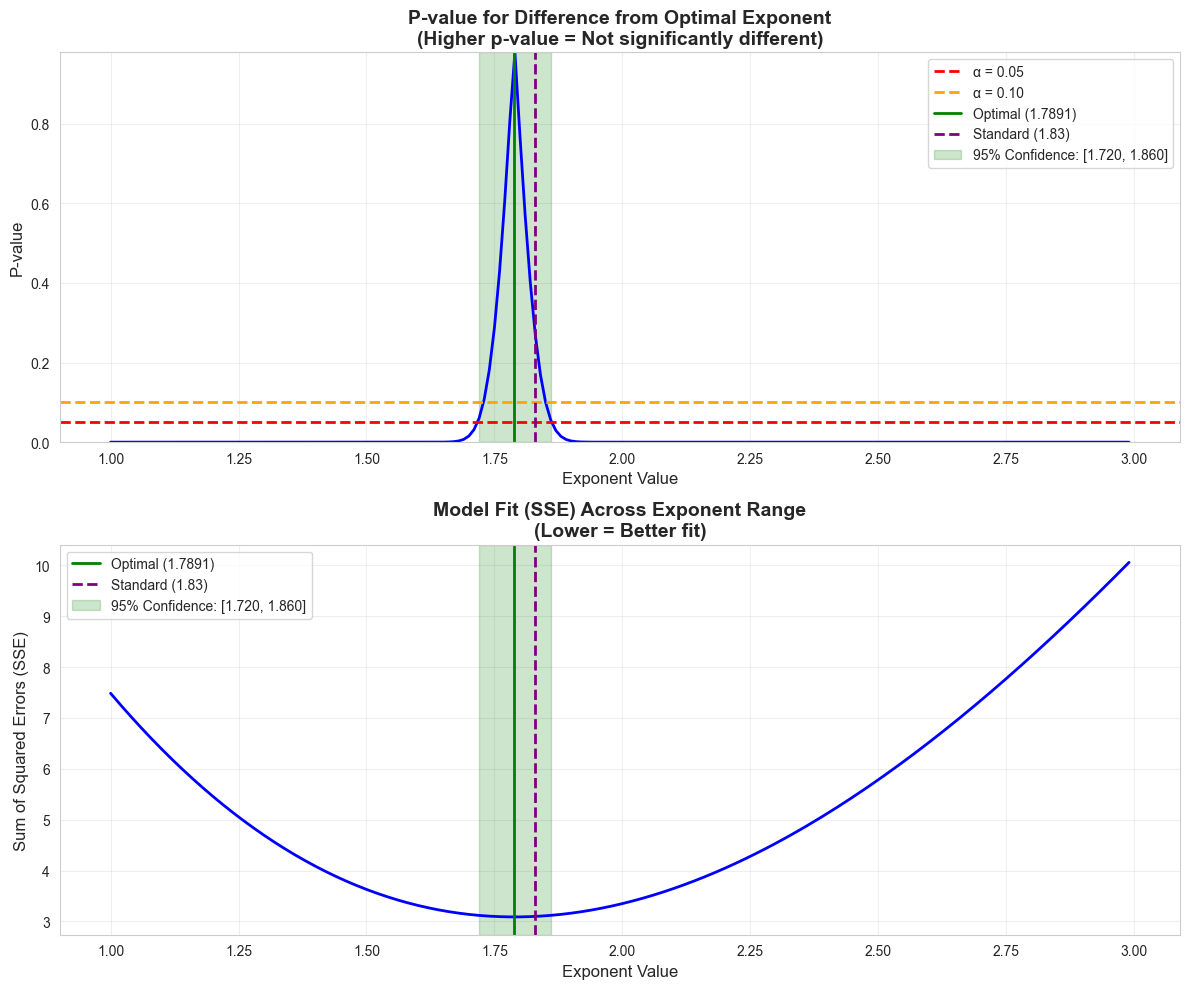


SUMMARY TABLE

 Exponent      P-value      SSE    Can Use?
     1.70 1.527392e-02 3.137015  ✗ (p<0.05)
     1.75 2.876044e-01 3.096949 ✓✓ (p>0.10)
     1.80 7.669108e-01 3.088242 ✓✓ (p>0.10)
     1.83 2.680300e-01 3.097706 ✓✓ (p>0.10)
     1.85 9.988621e-02 3.110019  ✓ (p>0.05)
     1.90 2.920407e-03 3.161410  ✗ (p<0.05)
     1.95 1.857071e-05 3.241557  ✗ (p<0.05)
     2.00 2.762749e-08 3.349608  ✗ (p<0.05)

Legend: ✓✓ = Very safe to use  |  ✓ = Safe to use  |  ✗ = Significantly different

Bounds saved to 'exponent_confidence_bounds.csv'

INTERPRETATION GUIDE

The confidence bounds tell you which exponents are "statistically equivalent" 
to the optimal exponent:

- If 1.83 falls within your 95% confidence bounds (α=0.05), then using 1.83
  is statistically justified even though it's not the exact optimal value.

- The wider the bounds, the more flexibility you have in choosing an exponent.

- A narrow bound suggests the data strongly prefers a specific exponent value.

For practical u

In [9]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize_scalar
from scipy.stats import t
import matplotlib.pyplot as plt

# Load the data
df = pd.read_csv('ncaabb_teamStats.csv')

df = df.rename(columns={
    'team': 'Team',
    'league': 'Conference',
    'year': 'Year',
    'W': 'Wins',
    'L': 'Losses',
    'WPCT': 'Win_Pct',
    'R (Batting)': 'R',
    'R (Pitching)': 'RA'
})

df = df[df['Year'].between(2021, 2025)]
df = df.dropna(subset=['Win_Pct', 'R', 'RA'])

def pythagorean_win_pct(runs_scored, runs_allowed, exponent):
    """Calculate Pythagorean win expectation"""
    return runs_scored**exponent / (runs_scored**exponent + runs_allowed**exponent)

def sum_squared_error(exponent, actual_win_pct, runs_scored, runs_allowed):
    """Calculate sum of squared errors"""
    predicted = pythagorean_win_pct(runs_scored, runs_allowed, exponent)
    return np.sum((actual_win_pct - predicted)**2)

def compare_exponents_pvalue(actual_win_pct, runs_scored, runs_allowed, exp1, exp2):
    """Get p-value comparing two exponents"""
    pred1 = pythagorean_win_pct(runs_scored, runs_allowed, exp1)
    pred2 = pythagorean_win_pct(runs_scored, runs_allowed, exp2)
    
    residuals1 = actual_win_pct - pred1
    residuals2 = actual_win_pct - pred2
    
    squared_errors1 = residuals1**2
    squared_errors2 = residuals2**2
    
    diff = squared_errors1 - squared_errors2
    n = len(diff)
    
    mean_diff = np.mean(diff)
    std_diff = np.std(diff, ddof=1)
    
    if std_diff == 0:
        return 1.0
    
    t_stat = mean_diff / (std_diff / np.sqrt(n))
    p_value = 2 * (1 - t.cdf(abs(t_stat), n - 1))
    
    return p_value

# Find optimal exponent
print("=" * 80)
print("FINDING CONFIDENCE BOUNDS FOR PYTHAGOREAN EXPONENT")
print("=" * 80)
print()

optimal_exp = minimize_scalar(
    sum_squared_error,
    bounds=(1.0, 3.0),
    method='bounded',
    args=(df['Win_Pct'].values, df['R'].values, df['RA'].values)
).x

print(f"Optimal Exponent: {optimal_exp:.4f}")
print(f"Sample Size: {len(df)} team-seasons")
print()

# Test range of exponents to find confidence bounds
print("FINDING NON-SIGNIFICANT BOUNDS (p > 0.05)")
print("-" * 80)

# Test exponents from 1.0 to 3.0
test_exponents = np.arange(1.0, 3.0, 0.01)
p_values = []

print("Testing exponents... (this may take a moment)")

for exp in test_exponents:
    p_val = compare_exponents_pvalue(
        df['Win_Pct'].values,
        df['R'].values,
        df['RA'].values,
        optimal_exp,
        exp
    )
    p_values.append(p_val)

# Find bounds at different significance levels
significance_levels = [0.05, 0.10, 0.20]
results = {}

for alpha in significance_levels:
    # Find exponents where p-value > alpha (not significantly different)
    non_sig_mask = np.array(p_values) > alpha
    non_sig_exponents = test_exponents[non_sig_mask]
    
    if len(non_sig_exponents) > 0:
        lower_bound = non_sig_exponents.min()
        upper_bound = non_sig_exponents.max()
        results[alpha] = (lower_bound, upper_bound)
    else:
        results[alpha] = (None, None)

print()
print("CONFIDENCE BOUNDS RESULTS")
print("=" * 80)
print()

for alpha in significance_levels:
    if results[alpha][0] is not None:
        lower, upper = results[alpha]
        print(f"Significance Level: α = {alpha:.2f} (p > {alpha:.2f})")
        print(f"  Bounds: [{lower:.4f}, {upper:.4f}]")
        print(f"  Range width: {upper - lower:.4f}")
        print(f"  Interpretation: Any exponent in this range is NOT significantly")
        print(f"                  different from the optimal ({optimal_exp:.4f})")
        print()

# Specific check for 1.83
p_183 = compare_exponents_pvalue(
    df['Win_Pct'].values,
    df['R'].values,
    df['RA'].values,
    optimal_exp,
    1.83
)

print("SPECIFIC CHECK FOR EXPONENT = 1.83")
print("-" * 80)
print(f"P-value comparing optimal ({optimal_exp:.4f}) vs 1.83: {p_183:.4f}")
if p_183 > 0.05:
    print(f"✓ 1.83 is NOT significantly different (p > 0.05)")
    print(f"  → You can use 1.83 with confidence")
else:
    print(f"✗ 1.83 IS significantly different (p < 0.05)")
    print(f"  → Using the optimal exponent is recommended")
print()

# Create visualization
print("\nCREATING VISUALIZATION...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: P-values across exponent range
ax1.plot(test_exponents, p_values, linewidth=2, color='blue')
ax1.axhline(y=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
ax1.axhline(y=0.10, color='orange', linestyle='--', linewidth=2, label='α = 0.10')
ax1.axvline(x=optimal_exp, color='green', linestyle='-', linewidth=2, label=f'Optimal ({optimal_exp:.4f})')
ax1.axvline(x=1.83, color='purple', linestyle='--', linewidth=2, label='Standard (1.83)')

# Shade non-significant region (p > 0.05)
if results[0.05][0] is not None:
    ax1.axvspan(results[0.05][0], results[0.05][1], alpha=0.2, color='green', 
                label=f'95% Confidence: [{results[0.05][0]:.3f}, {results[0.05][1]:.3f}]')

ax1.set_xlabel('Exponent Value', fontsize=12)
ax1.set_ylabel('P-value', fontsize=12)
ax1.set_title('P-value for Difference from Optimal Exponent\n(Higher p-value = Not significantly different)', 
              fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0, max(0.5, max(p_values))])

# Plot 2: SSE across exponent range
sse_values = []
for exp in test_exponents:
    sse = sum_squared_error(exp, df['Win_Pct'].values, df['R'].values, df['RA'].values)
    sse_values.append(sse)

ax2.plot(test_exponents, sse_values, linewidth=2, color='blue')
ax2.axvline(x=optimal_exp, color='green', linestyle='-', linewidth=2, label=f'Optimal ({optimal_exp:.4f})')
ax2.axvline(x=1.83, color='purple', linestyle='--', linewidth=2, label='Standard (1.83)')

# Shade non-significant region
if results[0.05][0] is not None:
    ax2.axvspan(results[0.05][0], results[0.05][1], alpha=0.2, color='green',
                label=f'95% Confidence: [{results[0.05][0]:.3f}, {results[0.05][1]:.3f}]')

ax2.set_xlabel('Exponent Value', fontsize=12)
ax2.set_ylabel('Sum of Squared Errors (SSE)', fontsize=12)
ax2.set_title('Model Fit (SSE) Across Exponent Range\n(Lower = Better fit)', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('exponent_confidence_bounds.png', dpi=300, bbox_inches='tight')
print("Visualization saved as 'exponent_confidence_bounds.png'")
plt.show()

# Create summary table
print("\n" + "=" * 80)
print("SUMMARY TABLE")
print("=" * 80)
print()

summary_data = []
for exp_test in [1.70, 1.75, 1.80, 1.83, 1.85, 1.90, 1.95, 2.00]:
    p_val = compare_exponents_pvalue(
        df['Win_Pct'].values,
        df['R'].values,
        df['RA'].values,
        optimal_exp,
        exp_test
    )
    sse = sum_squared_error(exp_test, df['Win_Pct'].values, df['R'].values, df['RA'].values)
    
    sig_marker = ""
    if p_val > 0.10:
        sig_marker = "✓✓ (p>0.10)"
    elif p_val > 0.05:
        sig_marker = "✓ (p>0.05)"
    else:
        sig_marker = "✗ (p<0.05)"
    
    summary_data.append({
        'Exponent': exp_test,
        'P-value': p_val,
        'SSE': sse,
        'Can Use?': sig_marker
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print()
print("Legend: ✓✓ = Very safe to use  |  ✓ = Safe to use  |  ✗ = Significantly different")
print()

# Export results
bounds_export = pd.DataFrame([
    {'Significance_Level': alpha, 
     'Lower_Bound': results[alpha][0], 
     'Upper_Bound': results[alpha][1],
     'Range_Width': results[alpha][1] - results[alpha][0] if results[alpha][0] else None}
    for alpha in significance_levels
])

bounds_export.to_csv('exponent_confidence_bounds.csv', index=False)
print("Bounds saved to 'exponent_confidence_bounds.csv'")
print()

print("=" * 80)
print("INTERPRETATION GUIDE")
print("=" * 80)
print("""
The confidence bounds tell you which exponents are "statistically equivalent" 
to the optimal exponent:

- If 1.83 falls within your 95% confidence bounds (α=0.05), then using 1.83
  is statistically justified even though it's not the exact optimal value.

- The wider the bounds, the more flexibility you have in choosing an exponent.

- A narrow bound suggests the data strongly prefers a specific exponent value.

For practical use:
- Use the optimal exponent for maximum accuracy
- Use 1.83 if it falls within your desired confidence level (easier to compare)
- Any exponent within the bounds is defensible statistically
""")